# ODMR Spectroscopy: Global Fitting of 8 Hyperfine-Split Resonances

This notebook implements a complete workflow for fitting ODMR (Optically Detected Magnetic Resonance) spectroscopy data from NV centers in diamond.

## Overview

ODMR spectroscopy reveals the magnetic resonance transitions of NV centers. Each transition appears as a **dip** in the fluorescence signal as a function of applied RF frequency. Due to the host lattice spin (¹⁴N I=1), each resonance line splits into **three hyperfine components** (transitions within the ±1 manifold).

This fitting code:
1. Detects the 8 broad ODMR dips (4 left of zero-field splitting D, 4 right)
2. Estimates and removes a polynomial baseline
3. Globally fits the baseline-corrected spectrum as **8 symmetric triplets**
4. Extracts physical parameters: center frequencies, hyperfine splitting, linewidths

**Key Physics:**
- Zero-field splitting: $D \approx 2.87$ GHz
- Hyperfine coupling (¹⁴N): $\Delta_{\text{hf}} \approx 2.16$ MHz
- Triplet structure due to three orientations of host nuclear spin

## Import Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit
import os

# For nicer output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

---

## Part 1: Model Functions

### Physical Model

We model the ODMR spectrum as a superposition of **8 independent hyperfine triplets**. Each triplet consists of three equally-spaced Lorentzian lines separated by the hyperfine splitting $\Delta_{\text{hf}}$.

**Global ODMR model:**

$$y(f) = 1 - \sum_{i=1}^{8} C_i \left[ w_{-1} L(f; f_{c,i} - \Delta_{\text{hf}}, \gamma) + w_0 L(f; f_{c,i}, \gamma) + w_{+1} L(f; f_{c,i} + \Delta_{\text{hf}}, \gamma) \right]$$

where:
- $L(f; f_0, \gamma)$ is a normalized Lorentzian with center $f_0$ and linewidth $\gamma$ (FWHM)
- $f_{c,i}$ is the center frequency of the $i$-th triplet (shared $f_c$ for all three lines)
- $C_i$ is the contrast (depth) of the $i$-th triplet
- $\Delta_{\text{hf}}$ is the **shared** hyperfine splitting (same for all 8 triplets)
- $\gamma$ is the **shared** homogeneous linewidth
- $w_{-1}, w_0, w_{+1}$ are **relative amplitudes** of the three hyperfine lines

By using a global shared $\Delta_{\text{hf}}$, $\gamma$, and weights, we enforce the physical expectation that hyperfine structure is uniform across the entire magnetic field range.

In [2]:
def lorentzian(x, x0, gamma):
    """
    Unit-height Lorentzian line.
    
    Mathematical form:
        L(x; x0, gamma) = 1 / (1 + 4*((x - x0)/gamma)^2)
    
    where gamma is the Full Width at Half Maximum (FWHM).
    
    Parameters
    ----------
    x : array
        Frequency grid
    x0 : float
        Center frequency (GHz)
    gamma : float
        FWHM linewidth (GHz)
    
    Returns
    -------
    array
        Values of Lorentzian line [0, 1]
    """
    return 1.0 / (1.0 + 4.0 * ((x - x0) / gamma) ** 2)


def global_odmr_model(x, *params):
    """
    Global fit model for ODMR spectrum with 8 aligned hyperfine triplets.
    
    The model assumes:
    - One shared hyperfine splitting delta_hf across all 8 dips
    - One shared linewidth gamma
    - Shared triplet weight ratios (w_m1, w_0, w_p1)
    
    Parameters (unpacked from *params)
    ----------
    f_c1, ..., f_c8 : float
        Center frequencies of the 8 ODMR dips (GHz)
    C1, ..., C8 : float
        Contrasts (depths) of each dip
    delta_hf : float
        Hyperfine splitting in GHz (~0.00216 for ¹⁴N)
    gamma : float
        Homogeneous linewidth (FWHM) in GHz
    w_m1, w_0, w_p1 : float
        Relative amplitudes of the three hyperfine lines
        (normalized internally)
    
    Returns
    -------
    array
        Model ODMR spectrum (baseline-corrected, should be near 1)
    """
    n_dips = 8
    centers = np.array(params[:n_dips])
    contrasts = np.array(params[n_dips:2 * n_dips])
    delta_hf = params[2 * n_dips]
    gamma = params[2 * n_dips + 1]
    w_m1 = params[2 * n_dips + 2]
    w_0  = params[2 * n_dips + 3]
    w_p1 = params[2 * n_dips + 4]

    # Normalize weights (ensures scale is in contrast C_i)
    wsum = w_m1 + w_0 + w_p1 + 1e-15
    w_m1 /= wsum
    w_0  /= wsum
    w_p1 /= wsum

    y = np.ones_like(x, dtype=float)

    # Subtract each of the 8 triplets
    for fc, C in zip(centers, contrasts):
        # Superposition of 3 Lorentzians making the hyperfine triplet
        triplet = (
            w_m1 * lorentzian(x, fc - delta_hf, gamma)
            + w_0 * lorentzian(x, fc, gamma)
            + w_p1 * lorentzian(x, fc + delta_hf, gamma)
        )
        y -= C * triplet

    return y

---

## Part 2: Data Preprocessing Functions

### Normalization and Smoothing

Before peak detection, we normalize the signal to [0, 1] and apply mild Savitzky-Golay filtering.

**Normalization:** Scales the raw ODMR signal to a standard dynamic range, making peak detection robust to absolute signal level.

**Smoothing:** The Savitzky-Golay filter preserves the overall shape while suppressing high-frequency noise. This improves the robustness of the peak detection step without biasing parameter extraction.

In [3]:
def normalize_signal(y):
    """
    Normalize raw signal to [0, 1] interval.
    
    Formula:
        y_norm = (y - min(y)) / (max(y) - min(y))
    
    This is used only for detection and visualization.
    The actual fitting is done on baseline-corrected raw data.
    
    Parameters
    ----------
    y : array
        Raw ODMR signal
    
    Returns
    -------
    array
        Normalized signal in [0, 1]
    """
    y = np.asarray(y, dtype=float)
    return (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-15)


def smooth_signal(y, window=9, poly=3):
    """
    Apply Savitzky-Golay smoothing for robust peak detection.
    
    The Savitzky-Golay filter fits a local polynomial to each point,
    preserving the underlying shape while reducing noise.
    
    Parameters
    ----------
    y : array
        Signal to smooth
    window : int
        Smoothing window length (must be odd)
    poly : int
        Polynomial order for local fit
    
    Returns
    -------
    array
        Smoothed signal
    """
    if window % 2 == 0:
        window += 1
    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)
    if window < 5:
        return y.copy()
    return savgol_filter(y, window_length=window, polyorder=poly)

---

## Part 3: Broad ODMR Dip Detection

### Algorithm: Find 4 Dips on Each Side of D

**Goal:** Identify approximate center frequencies of the 8 broad ODMR resonances.

**Method:**
1. Smooth the normalized spectrum
2. Invert the signal (dips → peaks for peak-finding algorithm)
3. Split the frequency range into left/right halves at $D = 2.87$ GHz
4. Use `scipy.signal.find_peaks` with a prominence threshold to find significant peaks
5. Keep the 4 most prominent peaks on each side

**Physical Motivation:**
- We know from ODMR theory that NV centers in a magnetic field produce 4 resonances on each side of the zero-field splitting
- By explicitly searching for exactly 4 peaks per side, we enforce this physical constraint
- This step is **not** attempting to resolve hyperfine structure; just finding broad dips

In [4]:
def detect_8_broad_dips(f_ghz, y_norm, D_GHz=2.87, fmin=2.79, fmax=2.96):
    """
    Detect the approximate center frequencies of the 8 broad ODMR dips.
    
    This does NOT resolve hyperfine structure—just finds broad resonances.
    
    Algorithm
    ---------
    1. Smooth the normalized trace
    2. Invert (1 - y_smooth) to turn dips into peaks
    3. Apply peak detection separately on left and right halves
    4. Select the 4 most prominent peaks on each side
    
    Parameters
    ----------
    f_ghz : array
        Frequency grid (GHz)
    y_norm : array
        Normalized ODMR signal [0, 1]
    D_GHz : float
        Zero-field splitting center (GHz), default 2.87
    fmin, fmax : float
        Frequency range of interest (GHz)
    
    Returns
    -------
    dip_centers : array
        Approximate center frequencies of 8 broad dips (sorted)
    y_smooth : array
        Smoothed signal (for plotting)
    """
    y_smooth = smooth_signal(y_norm, window=9, poly=3)
    inv = 1.0 - y_smooth  # dips -> peaks

    left_mask = (f_ghz < D_GHz) & (f_ghz >= fmin)
    right_mask = (f_ghz > D_GHz) & (f_ghz <= fmax)

    def detect_side(mask):
        """Detect 4 peaks on one side."""
        f_side = f_ghz[mask]
        inv_side = inv[mask]

        peaks, props = find_peaks(
            inv_side, 
            prominence=0.01,  # minimum prominence threshold
            distance=8        # minimum spacing between peaks
        )

        if len(peaks) == 0:
            return np.array([])

        # Get prominence for each peak
        prominences = props["prominences"]
        
        # Keep only the 4 most prominent peaks
        strongest = np.argsort(prominences)[::-1][:4]
        peak_freqs = f_side[peaks[strongest]]
        
        return np.sort(peak_freqs)

    left_centers = detect_side(left_mask)
    right_centers = detect_side(right_mask)

    if len(left_centers) != 4 or len(right_centers) != 4:
        raise RuntimeError(
            f"Expected 4 left and 4 right dips, got {len(left_centers)} left and {len(right_centers)} right."
        )

    dip_centers = np.sort(np.concatenate([left_centers, right_centers]))
    return dip_centers, y_smooth

---

## Part 4: Polynomial Baseline Fitting

### Removing the Optical Background

ODMR measurements have an underlying optical baseline that varies slowly with frequency (typically due to detector response, optical filter transmission). We must remove this background before fitting the resonance structure.

**Method:**
1. Identify regions far from ODMR dips
2. Fit a low-order polynomial (degree 2) through these "on-resonance points"
3. Subtract the fitted baseline from the raw data

**Mathematical form:**
$$\text{baseline}(f) = a_0 + a_1 f + a_2 f^2$$

The baseline-corrected data is then:
$$y_{\text{corr}} = \frac{y_{\text{raw}}}{\text{baseline}}$$

This renormalization ensures that the corrected spectrum lives near a value of 1 away from dips.

In [5]:
def fit_polynomial_baseline(f_ghz, y, dip_centers, mask_halfwidth_GHz=0.006, deg=2):
    """
    Estimate a slowly varying polynomial baseline.
    
    This function masks out the regions around ODMR dips and fits a polynomial
    through the remaining "on-resonance" points, which represent the optical baseline.
    
    Algorithm
    ---------
    1. Create a mask that excludes regions around all 8 detected dips
    2. Fit a degree-2 polynomial to the unmasked points
    3. Evaluate the polynomial across the full frequency range
    
    Parameters
    ----------
    f_ghz : array
        Frequency grid (GHz)
    y : array
        Raw ODMR signal
    dip_centers : array
        Detected broad dip center frequencies
    mask_halfwidth_GHz : float
        Half-width of exclusion window around each dip (GHz)
    deg : int
        Polynomial degree (default 2 for slowly varying baseline)
    
    Returns
    -------
    baseline : array
        Fitted polynomial baseline values
    coeffs : array
        Polynomial coefficients (highest degree first)
    mask : array (bool)
        Boolean mask indicating which points were used for fitting
    """
    mask = np.ones_like(f_ghz, dtype=bool)

    # Exclude points around each detected dip
    for fc in dip_centers:
        mask &= np.abs(f_ghz - fc) > mask_halfwidth_GHz

    # Fallback: if too much was masked, use all points
    if np.sum(mask) < max(20, deg + 5):
        mask[:] = True

    # Fit polynomial through non-masked points
    coeffs = np.polyfit(f_ghz[mask], y[mask], deg=deg)
    baseline = np.polyval(coeffs, f_ghz)

    return baseline, coeffs, mask

---

## Part 5: Global ODMR Fitting

### Complete Workflow

This is the main function that orchestrates all steps:
1. Read and crop data to the ODMR region (2.79–2.96 GHz)
2. Detect the 8 broad dip centers
3. Fit and remove the polynomial baseline
4. Perform global least-squares fit to the baseline-corrected spectrum
5. Extract and return all fitted parameters and diagnostics


In [6]:
def fit_global_odmr(df, D_GHz=2.87, fmin=2.79, fmax=2.96):
    """
    Full global ODMR fitting workflow.
    
    Steps
    -----
    1. Read and restrict to frequency range of interest
    2. Normalize signal and detect 8 broad dip centers
    3. Fit polynomial baseline from off-resonance points
    4. Divde raw data by baseline to get baseline-corrected spectrum
    5. Perform global least-squares fit of all 8 triplets simultaneously
    6. Extract fitted parameters and compute residuals
    
    Parameters
    ----------
    df : pd.DataFrame
        Input CSV data with columns [Frequency (Hz), ODMR_signal]
    D_GHz : float
        Zero-field splitting center (GHz)
    fmin, fmax : float
        Frequency range for analysis (GHz)
    
    Returns
    -------
    results_df : pd.DataFrame
        Table with fitted parameters for each dip
    payload : dict
        Detailed results and intermediate data for plotting
    """
    # ---------------------------
    # Read and crop data
    # ---------------------------
    f_hz = df.iloc[:, 0].to_numpy(dtype=float)
    y_raw = df.iloc[:, 1].to_numpy(dtype=float)
    f_ghz = f_hz / 1e9

    roi = (f_ghz >= fmin) & (f_ghz <= fmax)
    f_ghz = f_ghz[roi]
    y_raw = y_raw[roi]

    # ---------------------------
    # Broad dip detection on normalized trace
    # ---------------------------
    y_norm = normalize_signal(y_raw)
    dip_centers, y_smooth = detect_8_broad_dips(
        f_ghz, y_norm, D_GHz=D_GHz, fmin=fmin, fmax=fmax
    )

    # ---------------------------
    # Polynomial baseline correction
    # ---------------------------
    baseline_raw, baseline_coeffs, baseline_mask = fit_polynomial_baseline(
        f_ghz, y_raw, dip_centers, mask_halfwidth_GHz=0.006, deg=2
    )

    # Division by baseline gives the baseline-corrected spectrum
    y_corr = y_raw / (baseline_raw + 1e-15)

    # renormalization for numerical convenience
    median_top = np.median(np.sort(y_corr)[-max(10, len(y_corr)//10):])
    y_fit = y_corr / (median_top + 1e-15)

    # ---------------------------
    # Initial parameter guesses
    # ---------------------------
    n_dips = 8
    centers0 = dip_centers.copy()

    # Estimate contrast (depth) of each broad dip
    contrasts0 = []
    for fc in centers0:
        local = np.abs(f_ghz - fc) < 0.004
        if np.any(local):
            depth = 1.0 - np.min(y_fit[local])
            contrasts0.append(max(0.005, depth))
        else:
            contrasts0.append(0.02)
    contrasts0 = np.array(contrasts0)

    delta0 = 0.00216   # 14N hyperfine splitting in GHz
    gamma0 = 0.0010    # Initial linewidth guess (GHz)
    w0 = [1.0, 1.0, 1.0]  # Equal weights initially

    p0 = np.concatenate([centers0, contrasts0, [delta0, gamma0], w0])

    # ---------------------------
    # Parameter bounds
    # ---------------------------
    # Allow small variations around initial center estimates
    lower_centers = centers0 - 0.004
    upper_centers = centers0 + 0.004

    lower_contrasts = np.full(n_dips, 0.0)
    upper_contrasts = np.full(n_dips, 0.5)

    lower = np.concatenate([
        lower_centers,
        lower_contrasts,
        [0.0015, 0.0002],   # delta_hf, gamma
        [0.0, 0.0, 0.0]     # weights
    ])

    upper = np.concatenate([
        upper_centers,
        upper_contrasts,
        [0.0030, 0.0040],   # delta_hf, gamma
        [5.0, 5.0, 5.0]     # weights
    ])

    # ---------------------------
    # Global least-squares fit
    # ---------------------------
    print("Performing global least-squares fit...")
    popt, pcov = curve_fit(
        global_odmr_model,
        f_ghz,
        y_fit,
        p0=p0,
        bounds=(lower, upper),
        maxfev=50000
    )

    y_model = global_odmr_model(f_ghz, *popt)
    residuals = y_fit - y_model
    rms = float(np.sqrt(np.mean(residuals**2)))
    print(f"Global fit RMS residual: {rms:.6f}")

    # ---------------------------
    # Unpack and organize fitted parameters
    # ---------------------------
    centers = np.array(popt[:n_dips])
    contrasts = np.array(popt[n_dips:2*n_dips])
    delta_hf = float(popt[2*n_dips])
    gamma = float(popt[2*n_dips + 1])
    w_m1, w_0, w_p1 = popt[2*n_dips + 2:2*n_dips + 5]

    # Normalize weights for reporting
    wsum = w_m1 + w_0 + w_p1 + 1e-15
    w_m1, w_0, w_p1 = w_m1/wsum, w_0/wsum, w_p1/wsum

    # Sort by center frequency
    order = np.argsort(centers)
    centers = centers[order]
    contrasts = contrasts[order]

    # ---------------------------
    # Build results table
    # ---------------------------
    rows = []
    for i, (fc, C) in enumerate(zip(centers, contrasts), start=1):
        x0 = fc - delta_hf
        x1 = fc
        x2 = fc + delta_hf

        rows.append({
            "dip_id": i,
            "dip_side": "left" if fc < D_GHz else "right",
            "center_GHz": fc,
            "x0_GHz": x0,
            "x1_GHz": x1,
            "x2_GHz": x2,
            "contrast": C,
            "hf01_MHz": (x1 - x0) * 1000,
            "hf12_MHz": (x2 - x1) * 1000,
            "gamma_MHz": gamma * 1000,
            "w_m1": w_m1,
            "w_0": w_0,
            "w_p1": w_p1,
            "global_fit_rms": rms,
        })

    results_df = pd.DataFrame(rows).sort_values("center_GHz").reset_index(drop=True)

    # Collect all results into a payload dictionary for plotting
    payload = {
        "f_ghz": f_ghz,
        "y_raw": y_raw,
        "y_norm": y_norm,
        "y_smooth": y_smooth,
        "baseline_raw": baseline_raw,
        "baseline_coeffs": baseline_coeffs,
        "baseline_mask": baseline_mask,
        "y_fit": y_fit,
        "y_model": y_model,
        "residuals": residuals,
        "dip_centers_init": dip_centers,
        "centers_fit": centers,
        "contrasts_fit": contrasts,
        "delta_hf_GHz": delta_hf,
        "gamma_GHz": gamma,
        "weights_fit": (w_m1, w_0, w_p1),
        "D_GHz": D_GHz,
        "global_rms": rms,
        "popt": popt,
        "pcov": pcov,
    }

    return results_df, payload

---

## Part 6: Example Usage

### Load Data and Perform Fitting

In [ ]:
variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']

for variation in variations:
    output_dir = f'./{variation}'
    os.makedirs(output_dir, exist_ok=True)
    
    data_dir = f'../avareged_data/outputs/{variation}'
    files = [f for f in os.listdir(data_dir) if f.endswith('_averaged.csv')]
    
    for file in files:
        file_path = os.path.join(data_dir, file)
        df = pd.read_csv(file_path, sep='\t')
        
        print(f"Processing {variation}/{file}")
        
        results_df, payload = fit_global_odmr(df)
        
        # Save results to CSV
        base_name = file.replace('_averaged.csv', '')
        results_df.to_csv(os.path.join(output_dir, f'{base_name}_results.csv'), index=False)
        
        
        # Plot and save global fit
        plt.figure(figsize=(12, 6))
        plt.plot(payload["f_ghz"], payload["y_fit"], color="black", lw=1.2, label="baseline-corrected data")
        plt.plot(payload["f_ghz"], payload["y_model"], color="tab:red", lw=2, label="global 8-triplet fit")
        plt.axvline(payload["D_GHz"], color="red", linestyle=":", alpha=0.7, linewidth=2, label="D = 2.87 GHz")
        for fc in payload["centers_fit"]:
            plt.axvline(fc, color="gray", linestyle="--", alpha=0.25, linewidth=0.8)
        plt.xlim(2.79, 2.96)
        plt.xlabel("Frequency (GHz)", fontsize=12)
        plt.ylabel("Baseline-corrected ODMR", fontsize=12)
        plt.title("Global ODMR Fit: 8 Symmetric Hyperfine Triplets", fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'{base_name}_fit.png'), dpi=300)
        plt.close()
        
        # Plot and save residuals
        plt.figure(figsize=(12, 3.5))
        plt.plot(payload["f_ghz"], payload["residuals"], color="tab:green", lw=1, label="residuals")
        plt.axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=1)
        plt.xlim(2.79, 2.96)
        plt.xlabel("Frequency (GHz)", fontsize=12)
        plt.ylabel("Residual (data - model)", fontsize=12)
        plt.title("Global Fit Residuals", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'{base_name}_residuals.png'), dpi=300)
        plt.close()
        
        print(f"Saved results and plots for {base_name}")

Processing Variation Along X/0cm-0.3mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.000729
Saved results and plots for 0cm-0.3mm
Processing Variation Along X/0cm-0.0mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.000725
Saved results and plots for 0cm-0.0mm
Processing Variation Along X/0cm-0.1mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.000550
Saved results and plots for 0cm-0.1mm
Processing Variation Along X/0cm-0.4mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.000643
Saved results and plots for 0cm-0.4mm
Processing Variation Along X/0cm-0.2mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.000719
Saved results and plots for 0cm-0.2mm
Processing Variation Along Y/0cm-0.3mm_averaged.csv
Performing global least-squares fit...
Global fit RMS residual: 0.001127
Saved results and plots for 0cm-0.3mm
Processing Variation A

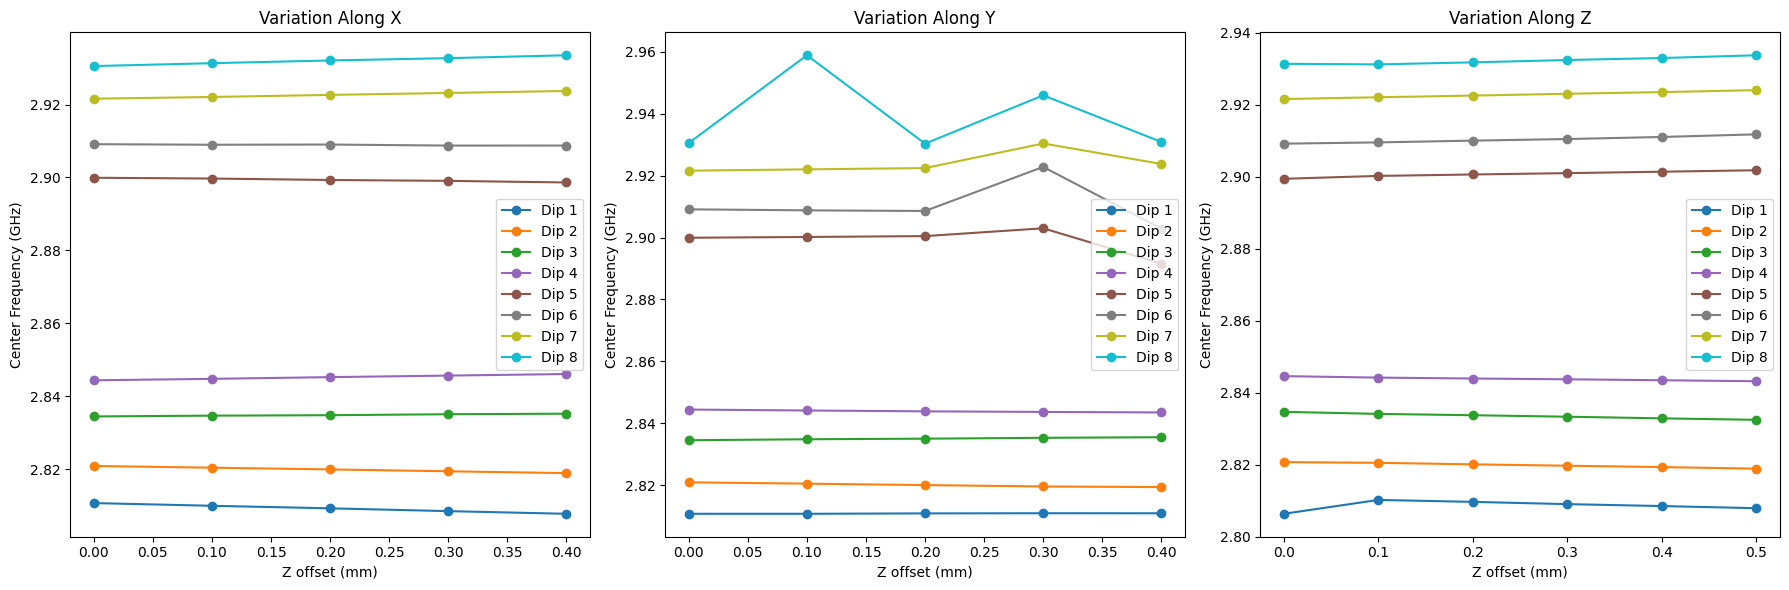

In [15]:
import matplotlib.pyplot as plt

variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, variation in enumerate(variations):
    ax = axes[i]
    output_dir = f'./{variation}'
    files = [f for f in os.listdir(output_dir) if f.endswith('_results.csv')]
    
    def get_offset(f):
        base = f.replace('_results.csv', '')
        parts = base.split('-')
        offset_str = parts[1].replace('mm', '')
        return float(offset_str)
    
    files.sort(key=get_offset)
    offsets = [get_offset(f) for f in files]
    
    dip_centers = {j: [] for j in range(1, 9)}
    
    for f in files:
        df = pd.read_csv(os.path.join(output_dir, f))
        for _, row in df.iterrows():
            dip_id = int(row['dip_id'])
            center = row['center_GHz']
            dip_centers[dip_id].append(center)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 8))
    for dip_id in range(1, 9):
        ax.plot(offsets, dip_centers[dip_id], 'o-', color=colors[dip_id-1], label=f'Dip {dip_id}')
    
    ax.set_xlabel('Z offset (mm)')
    ax.set_ylabel('Center Frequency (GHz)')
    ax.set_title(f'{variation}')
    ax.legend()

plt.tight_layout()
plt.savefig('variation_overlay.png', dpi=300)
plt.show()